## Visualization code for tensorboard logs 

In [6]:
import argparse, os, re, math, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tbparse import SummaryReader

In [15]:
# List of log directories
log_dirs_cartesian_increment = [
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-cartesian_increment-position-20250813-173245",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-cartesian_increment-position-20250813-184211",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-cartesian_increment-position-20250813-195126",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-cartesian_increment-position-20250813-210045",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-cartesian_increment-position-20250813-221001"
]


In [16]:
log_dirs_position_increment = [
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-position-20250814-045703",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-position-20250814-060634",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-position-20250814-071634",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-position-20250814-082542",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-position-20250814-093536"
]

In [18]:
log_dirs_velocity_increment = [
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-velocity-20250814-034917",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-velocity-20250814-024150",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-velocity-20250814-013420",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-velocity-20250814-002648",
    "/home/chemist/Desktop/ICRA2026/training/logs/PandaPickCubeCartesianModified-joint_increment-velocity-20250813-231921"
]

In [24]:
def plot_scalar(tag_to_plot, window_size):
    # Initialize empty DataFrames for both sets of logs
    combined_cartesian_df = pd.DataFrame()
    combined_position_df = pd.DataFrame()
    combined_velocity_df = pd.DataFrame()

    # Process Cartesian Increment logs
    for log_dir in log_dirs_cartesian_increment:
        reader = SummaryReader(log_dir)
        df = reader.scalars
        filtered_df = df[df['tag'] == tag_to_plot]
        filtered_df['smoothed_value'] = filtered_df['value'].rolling(window=window_size, min_periods=1).mean()
        filtered_df['log_dir'] = log_dir
        combined_cartesian_df = pd.concat([combined_cartesian_df, filtered_df], ignore_index=True)

    # Process Position Increment logs
    for log_dir in log_dirs_position_increment:
        reader = SummaryReader(log_dir)
        df = reader.scalars
        filtered_df = df[df['tag'] == tag_to_plot]
        filtered_df['smoothed_value'] = filtered_df['value'].rolling(window=window_size, min_periods=1).mean()
        filtered_df['log_dir'] = log_dir
        combined_position_df = pd.concat([combined_position_df, filtered_df], ignore_index=True)


    for log_dir in log_dirs_velocity_increment:
        reader = SummaryReader(log_dir)
        df = reader.scalars
        filtered_df = df[df['tag'] == tag_to_plot]
        filtered_df['smoothed_value'] = filtered_df['value'].rolling(window=window_size, min_periods=1).mean()
        filtered_df['log_dir'] = log_dir
        combined_velocity_df = pd.concat([combined_velocity_df, filtered_df], ignore_index=True)

    # Group by step and calculate mean and standard error for both sets
    grouped_cartesian_df = combined_cartesian_df.groupby('step')['smoothed_value'].agg(['mean', 'sem']).reset_index()
    grouped_position_df = combined_position_df.groupby('step')['smoothed_value'].agg(['mean', 'sem']).reset_index()
    grouped_velocity_df = combined_velocity_df.groupby('step')['smoothed_value'].agg(['mean', 'sem']).reset_index()

    # Plot both sets of logs
    plt.figure(figsize=(12, 8))

    # Cartesian Increment plot
    plt.plot(grouped_cartesian_df['step'], grouped_cartesian_df['mean'], linestyle='-', label='Cartesian Increment (Mean)', color='blue')
    plt.fill_between(grouped_cartesian_df['step'], 
                    grouped_cartesian_df['mean'] - grouped_cartesian_df['sem'], 
                    grouped_cartesian_df['mean'] + grouped_cartesian_df['sem'], 
                    color='blue', alpha=0.2, label='Cartesian Increment (Std Error)')

    # Position Increment plot
    plt.plot(grouped_position_df['step'], grouped_position_df['mean'], linestyle='-', label='Position Increment (Mean)', color='orange')
    plt.fill_between(grouped_position_df['step'], 
                    grouped_position_df['mean'] - grouped_position_df['sem'], 
                    grouped_position_df['mean'] + grouped_position_df['sem'], 
                    color='orange', alpha=0.2, label='Position Increment (Std Error)')

    # Velocity Increment plot
    plt.plot(grouped_velocity_df['step'], grouped_velocity_df['mean'], linestyle='-', label='Velocity Increment (Mean)', color='green')
    plt.fill_between(grouped_velocity_df['step'],
                    grouped_velocity_df['mean'] - grouped_velocity_df['sem'], 
                    grouped_velocity_df['mean'] + grouped_velocity_df['sem'], 
                    color='green', alpha=0.2, label='Velocity Increment (Std Error)')

    # Add labels and legend
    plt.xlabel('Step')
    plt.ylabel('Value')
    plt.title(f'Comparison of {tag_to_plot} between Cartesian, Position, and Velocity Increment')
    plt.legend()
    plt.grid()
    plt.show()

/tmp/ipykernel_3310758/2945957026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['smoothed_value'] = filtered_df['value'].rolling(window=window_size, min_periods=1).mean()
/tmp/ipykernel_3310758/2945957026.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['log_dir'] = log_dir
/tmp/ipykernel_3310758/2945957026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

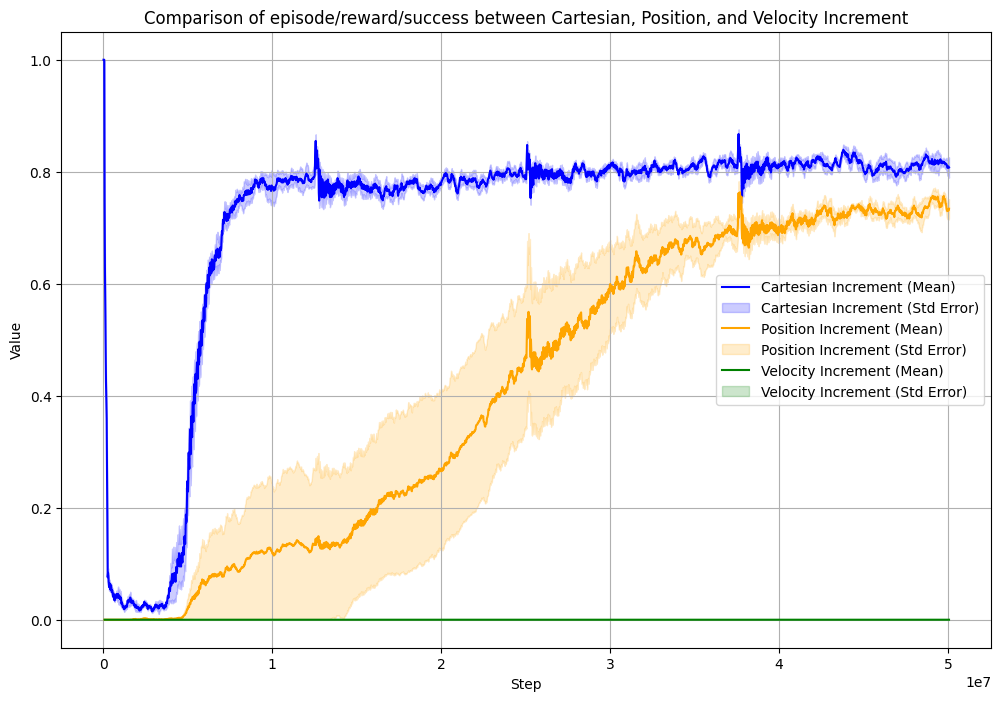

In [25]:
plot_scalar(tag_to_plot = "episode/reward/success", window_size = 10)

/tmp/ipykernel_3310758/2945957026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['smoothed_value'] = filtered_df['value'].rolling(window=window_size, min_periods=1).mean()
/tmp/ipykernel_3310758/2945957026.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['log_dir'] = log_dir
/tmp/ipykernel_3310758/2945957026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

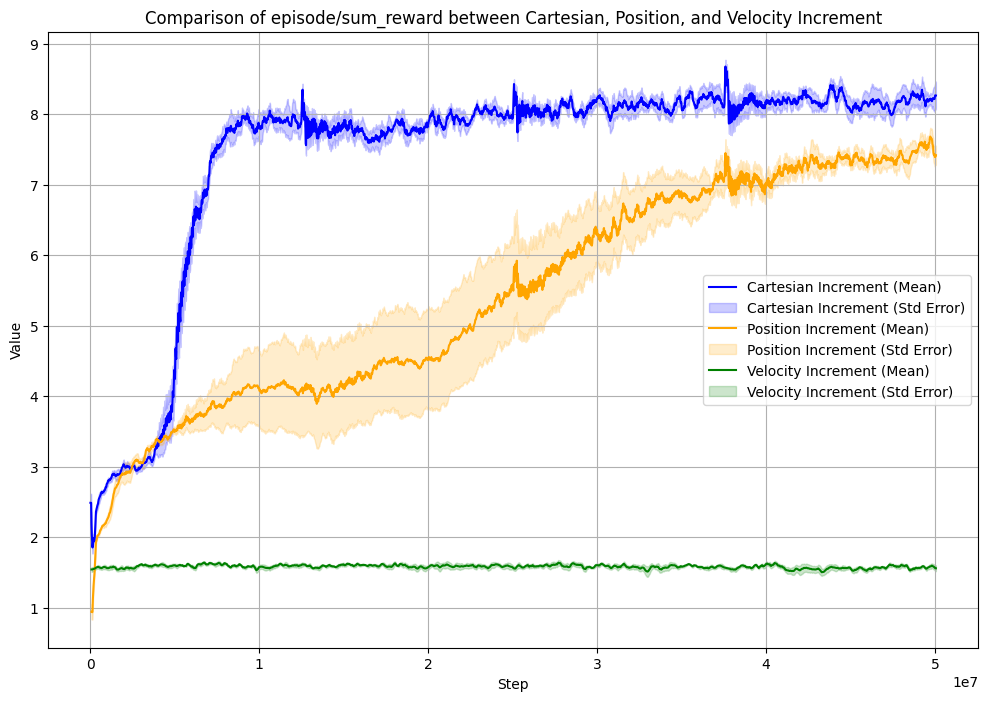

In [27]:
plot_scalar(tag_to_plot = "episode/sum_reward", window_size = 10)

/tmp/ipykernel_3310758/2945957026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['smoothed_value'] = filtered_df['value'].rolling(window=window_size, min_periods=1).mean()
/tmp/ipykernel_3310758/2945957026.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['log_dir'] = log_dir
/tmp/ipykernel_3310758/2945957026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

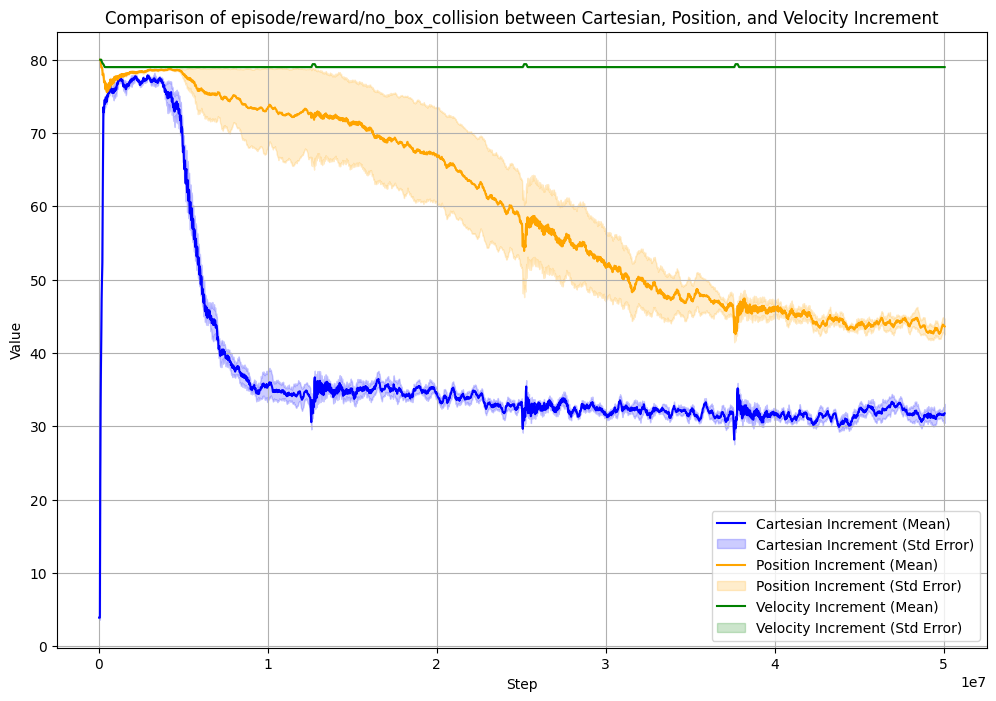

In [28]:
plot_scalar(tag_to_plot = "episode/reward/no_box_collision", window_size = 10)

/tmp/ipykernel_3310758/2945957026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['smoothed_value'] = filtered_df['value'].rolling(window=window_size, min_periods=1).mean()
/tmp/ipykernel_3310758/2945957026.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['log_dir'] = log_dir
/tmp/ipykernel_3310758/2945957026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

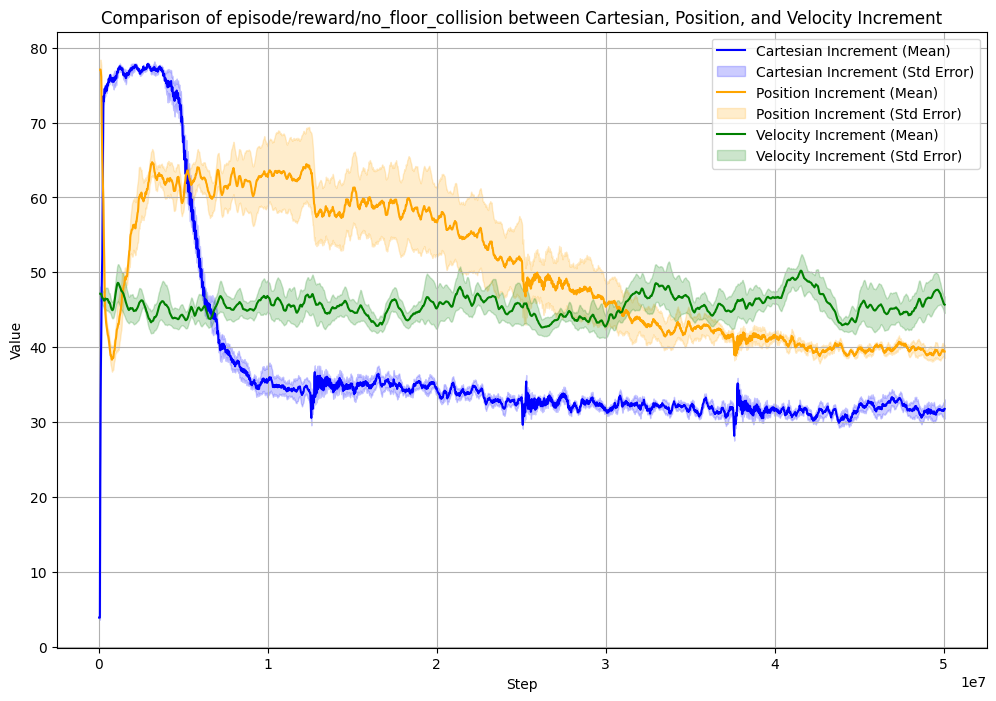

In [29]:
plot_scalar(tag_to_plot = "episode/reward/no_floor_collision", window_size = 10)